In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
import yfinance as yf
import pyvinecopulib as pv

In [4]:
tickers = ["SPY", "BAC"]

data = yf.download(
    tickers,
    start="2000-01-01",
    end="2026-01-01",
    auto_adjust=False
)

[*********************100%***********************]  2 of 2 completed


In [5]:
data.head()

Price       Adj Close                Close                High             \
Ticker            BAC        SPY       BAC       SPY       BAC        SPY   
Date                                                                        
2000-01-03  12.230103  91.132782  24.21875  145.4375  25.12500  148.25000   
2000-01-04  11.504189  87.568878  22.78125  139.7500  23.96875  144.06250   
2000-01-05  11.630439  87.725563  23.03125  140.0000  23.21875  141.53125   
2000-01-06  12.624625  86.315674  25.00000  137.7500  25.00000  141.50000   
2000-01-07  12.293227  91.328568  24.34375  145.7500  24.81250  145.75000   

Price            Low                  Open               Volume            
Ticker           BAC         SPY       BAC        SPY       BAC       SPY  
Date                                                                       
2000-01-03  24.00000  143.875000  25.12500  148.25000  13705800   8164300  
2000-01-04  22.46875  139.640625  23.87500  143.53125  27293400   8089800  
2000-01-05  22.25000  137.250000  22.53125  139.93750  22855600  12177900  
2000-01-06  23.37500  137.750000  23.46875  139.62500  17307000   6227200  
2000-01-07  24.00000  140.062500  24.81250  140.31250  11632800   8066500

In [6]:
data.columns

MultiIndex([('Adj Close', 'BAC'),
            ('Adj Close', 'SPY'),
            (    'Close', 'BAC'),
            (    'Close', 'SPY'),
            (     'High', 'BAC'),
            (     'High', 'SPY'),
            (      'Low', 'BAC'),
            (      'Low', 'SPY'),
            (     'Open', 'BAC'),
            (     'Open', 'SPY'),
            (   'Volume', 'BAC'),
            (   'Volume', 'SPY')],
           names=['Price', 'Ticker'])

In [7]:
# Select adjusted close prices
spy_price = data["Adj Close"]["SPY"].dropna()
bac_price = data["Adj Close"]["BAC"].dropna()

# Convert daily prices to month-end prices
spy_monthly = spy_price.resample("ME").last()
bac_monthly = bac_price.resample("ME").last()

# Calculate monthly log-returns
spy_returns = np.log(spy_monthly / spy_monthly.shift(1)).dropna()
bac_returns = np.log(bac_monthly / bac_monthly.shift(1)).dropna()

# Keep only months where both returns are available
returns = pd.concat(
    [spy_returns.rename("X"), bac_returns.rename("Y")],
    axis=1,
    join="inner"
).dropna()

# Basic information requested in 1a
print("Number of observations:", len(returns))
print("First month:", returns.index[0])
print("Last month:", returns.index[-1])

returns.head()

Number of observations: 311
First month: 2000-02-29 00:00:00
Last month: 2025-12-31 00:00:00


,X,Y
Date,,
2000-02-29,-0.015343,-0.051633
2000-03-31,0.092502,0.141910
2000-04-30,-0.035752,-0.067802
2000-05-31,-0.015847,0.132579
2000-06-30,0.019490,-0.254057


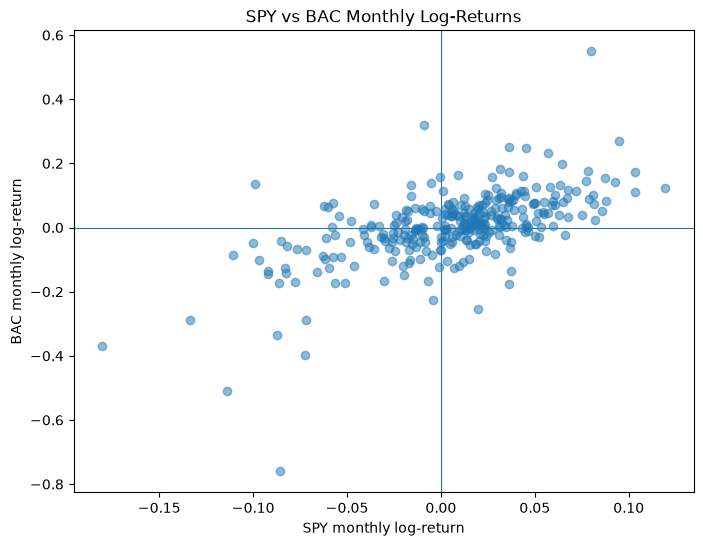

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    returns["X"],
    returns["Y"],
    alpha=0.5
)

plt.xlabel("SPY monthly log-return")
plt.ylabel("BAC monthly log-return")
plt.title("SPY vs BAC Monthly Log-Returns")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.show()

In [10]:
q_spy_05 = np.quantile(returns["X"], 0.05)
q_bac_05 = np.quantile(returns["Y"], 0.05)

print("SPY 5% quantile:", q_spy_05)
print("BAC 5% quantile:", q_bac_05)

SPY 5% quantile: -0.0798434239370544
BAC 5% quantile: -0.15719050412859262


In [11]:
joint_bad = (
    (returns["X"] <= q_spy_05) &
    (returns["Y"] <= q_bac_05)
)

frequency = joint_bad.mean()

print("Joint lower-tail frequency:", frequency)

Joint lower-tail frequency: 0.01929260450160772


In [ ]:
#problem 2

In [12]:
from scipy.stats import pearsonr, kendalltau

pearson = pearsonr(returns["X"], returns["Y"]).statistic
kendall = kendalltau(returns["X"], returns["Y"]).statistic

print("Pearson correlation:", pearson)
print("Kendall's tau:", kendall)

Pearson correlation: 0.6054354798772723
Kendall's tau: 0.4208484597033503


In [13]:
def g(x):
    return np.sign(x) * np.log(1 + 250 * np.abs(x))

X_trans = g(returns["X"])
Y_trans = g(returns["Y"])

pearson_trans = pearsonr(X_trans, Y_trans).statistic
kendall_trans = kendalltau(X_trans, Y_trans).statistic

print("Original Pearson:", pearson)
print("Transformed Pearson:", pearson_trans)
print("Original Kendall:", kendall)
print("Transformed Kendall:", kendall_trans)

Original Pearson: 0.6054354798772723
Transformed Pearson: 0.5600913011234766
Original Kendall: 0.4208484597033503
Transformed Kendall: 0.4208484597033503


The transformation slightly reduces the Pearson correlation from 0.6054 to 0.5601 because it changes the numerical distances between observations. Kendall's \(\tau\) remains unchanged at 0.4208 because the strictly increasing transformation preserves the ranks of both variables.

Problem 3

In [14]:
mu_X = np.mean(returns["X"])
mu_Y = np.mean(returns["Y"])

print("SPY mean:", mu_X)
print("BAC mean:", mu_Y)

SPY mean: 0.006586909730542651
BAC mean: 0.004783035720901207


In [15]:
sigma_X = np.sqrt(np.mean((returns["X"] - mu_X)**2))
sigma_Y = np.sqrt(np.mean((returns["Y"] - mu_Y)**2))

print("SPY sigma:", sigma_X)
print("BAC sigma:", sigma_Y)

SPY sigma: 0.043860821996828475
BAC sigma: 0.11141116162363941


In [16]:
rho = pearson

cov_XY = rho * sigma_X * sigma_Y

Sigma = np.array([
    [sigma_X**2, cov_XY],
    [cov_XY, sigma_Y**2]
])

mu = np.array([mu_X, mu_Y])

print("Mean vector:")
print(mu)

print("\nCovariance matrix:")
print(Sigma)

Mean vector:
[0.00658691 0.00478304]

Covariance matrix:
[[0.00192377 0.00295851]
 [0.00295851 0.01241245]]


In [17]:
simulated = np.random.multivariate_normal(
    mean=mu,
    cov=Sigma,
    size=len(returns)
)

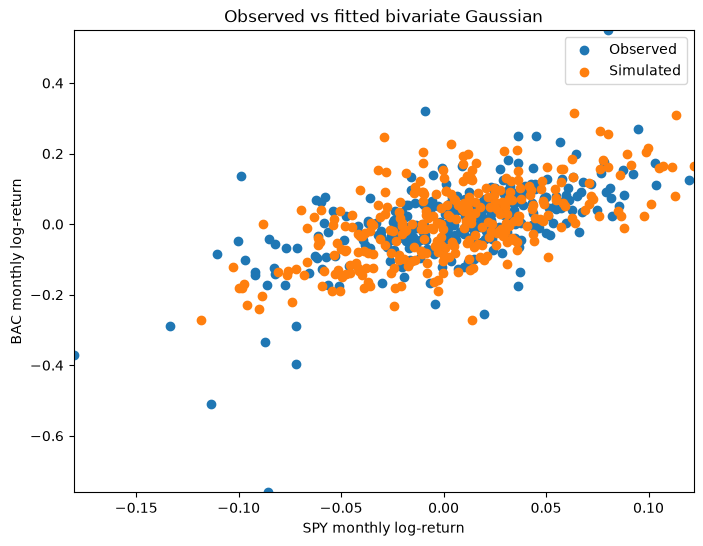

In [19]:
simulated = np.random.multivariate_normal(
    mean=mu,
    cov=Sigma,
    size=len(returns)
)

plt.figure(figsize=(8, 6))

plt.scatter(returns["X"], returns["Y"], label="Observed")
plt.scatter(simulated[:, 0], simulated[:, 1], label="Simulated")

# Same axis limits for both
x_min = min(returns["X"].min(), simulated[:, 0].min())
x_max = max(returns["X"].max(), simulated[:, 0].max())
y_min = min(returns["Y"].min(), simulated[:, 1].min())
y_max = max(returns["Y"].max(), simulated[:, 1].max())

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.xlabel("SPY monthly log-return")
plt.ylabel("BAC monthly log-return")
plt.title("Observed vs fitted bivariate Gaussian")
plt.legend()
plt.show()

The fitted bivariate Gaussian reproduces the general positive dependence and central shape of the observed data, but it appears to underestimate the occurrence of extreme observations.

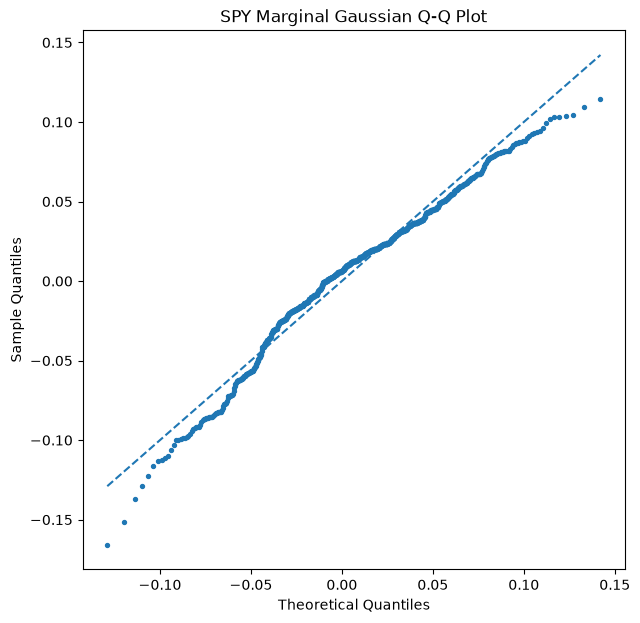

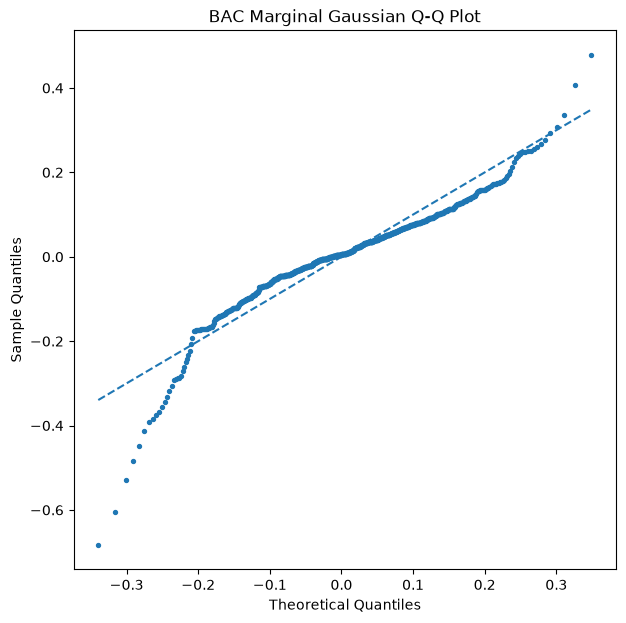

In [20]:
from scipy.special import ndtri

p = np.linspace(0.001, 0.999, 1000)

# SPY
theoretical_X = mu_X + sigma_X * ndtri(p)
sample_X = np.quantile(returns["X"], p)

# BAC
theoretical_Y = mu_Y + sigma_Y * ndtri(p)
sample_Y = np.quantile(returns["Y"], p)

# Q-Q plots
plt.figure(figsize=(7, 7))
plt.scatter(theoretical_X, sample_X, s=8)
plt.plot(theoretical_X, theoretical_X, "--")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.title("SPY Marginal Gaussian Q-Q Plot")
plt.show()

plt.figure(figsize=(7, 7))
plt.scatter(theoretical_Y, sample_Y, s=8)
plt.plot(theoretical_Y, theoretical_Y, "--")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.title("BAC Marginal Gaussian Q-Q Plot")
plt.show()

The fitted bivariate Gaussian captures the general dependence structure reasonably well, as shown by the scatterplot. However, the Q–Q plots reveal substantial deviations from the Gaussian marginal distributions, particularly in the tails. Therefore, the bivariate Gaussian appears adequate for the overall dependence pattern but is less adequate for the distribution of extreme returns.

Problem 4

In [21]:
n = len(returns)

U = returns["X"].rank() / (n + 1)
V = returns["Y"].rank() / (n + 1)

print(U.head())
print(V.head())

Date
2000-02-29    0.262821
2000-03-31    0.983974
2000-04-30    0.150641
2000-05-31    0.253205
2000-06-30    0.589744
Freq: ME, Name: X, dtype: float64
Date
2000-02-29    0.198718
2000-03-31    0.942308
2000-04-30    0.166667
2000-05-31    0.929487
2000-06-30    0.025641
Freq: ME, Name: Y, dtype: float64


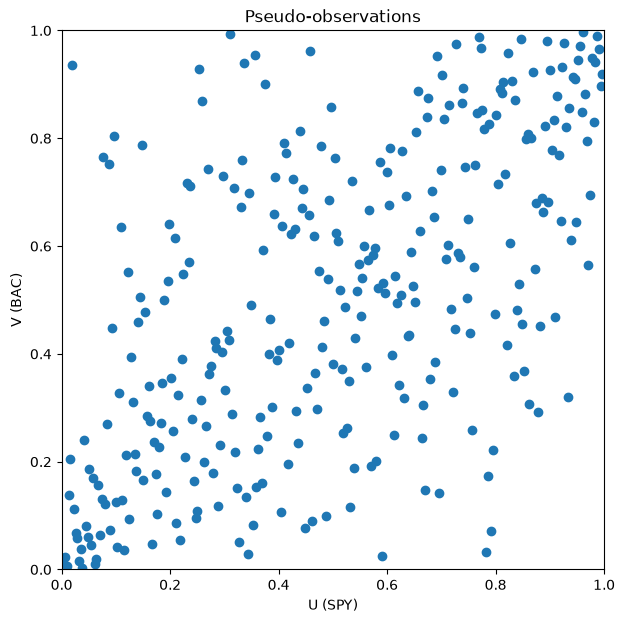

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(U, V)
plt.xlabel("U (SPY)")
plt.ylabel("V (BAC)")
plt.title("Pseudo-observations")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

We lose the actual magnitudes and marginal distributions of the returns, because only their ranks are retained. We retain the rank-based dependence between SPY and BAC. The transformation puts both variables on a common \((0,1)\) scale, making the dependence structure, including observations in the joint tails, easier to model with a copula.

In [26]:
import pyvinecopulib as pv
import numpy as np

uv = np.column_stack([U, V])

models = {
    "Gaussian": pv.Bicop.from_data(
        uv,
        controls=pv.FitControlsBicop(
            family_set=[pv.BicopFamily.gaussian]
        )
    ),
    "Student-t": pv.Bicop.from_data(
        uv,
        controls=pv.FitControlsBicop(
            family_set=[pv.BicopFamily.student]
        )
    ),
    "Gumbel": pv.Bicop.from_data(
        uv,
        controls=pv.FitControlsBicop(
            family_set=[pv.BicopFamily.gumbel],
            allow_rotations=True
        )
    ),
    "Independence": pv.Bicop.from_data(
        uv,
        controls=pv.FitControlsBicop(
            family_set=[pv.BicopFamily.indep]
        )
    )
}

for name, model in models.items():
    print(f"\n{name}")
    print("Family:", model.family)
    print("Rotation:", model.rotation)
    print("Parameters:", model.parameters)
    print("Log-likelihood:", model.loglik())
    print("BIC:", model.bic())


Gaussian
Family: BicopFamily.gaussian
Rotation: 0
Parameters: [[0.62027297]]
Log-likelihood: 72.80597005314057
BIC: -139.8721471941019

Student-t
Family: BicopFamily.student
Rotation: 0
Parameters: [[0.6218702 ]
 [5.67756937]]
Log-likelihood: 77.79440929227582
BIC: -144.10923276019315

Gumbel
Family: BicopFamily.gumbel
Rotation: 180
Parameters: [[1.71965026]]
Log-likelihood: 76.47584010179882
BIC: -147.2118872914184

Independence
Family: BicopFamily.indep
Rotation: 0
Parameters: []
Log-likelihood: 0.0
BIC: 0.0


The Gaussian, Student-t, Gumbel and independence copulas were fitted to the pseudo-observations. The Student-t copula has the highest pseudo log-likelihood (77.79), but the Gumbel copula with 180° rotation has the lowest BIC (-147.21). Therefore, according to the BIC criterion, the selected copula is the 180° rotated Gumbel copula. The selected rotation is consistent with stronger dependence in the lower tail.